<style>
/* Enable wrapping of long code lines */
code, pre {
    white-space: pre-wrap !important;
    word-wrap: break-word !important;
    overflow-wrap: break-word !important;
}
</style>

# Principal Component Analysis (PCA) of Twitter Dataset

In [47]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

df = pd.read_csv('/Users/tee._.thy/Desktop/ucd/davis y3/fq25/sta 160/Adjusted_Combined_Truth_Features.csv')


In [48]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    print(col, df[col].nunique())

author 161
statement_x 1058
manual_keywords 1056
tweet_x 134198
5_label_majority_answer 5
3_label_majority_answer 2
statement_y 1058
tweet_y 134198


In [49]:
for col in df.select_dtypes(include='number'):
    df[col] = pd.to_numeric(df[col], downcast='float')
for col in df.select_dtypes(include='object'):
    df[col] = df[col].astype('category')


In [50]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
for col in df.select_dtypes(include='category'):
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])


In [51]:
# cut off columns that have more than 20 unique values
low_card_cols = [col for col in categorical_cols if df[col].nunique() < 20]
df_small = df[low_card_cols + df.select_dtypes(include='number').columns.tolist()]
df_encoded = pd.get_dummies(df_small, drop_first=True)


In [52]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)


In [53]:
pca
principal_components

array([[ 0.59097705,  0.11931238],
       [ 2.00594874, -0.07247389],
       [-2.24957996,  0.054033  ],
       ...,
       [ 3.46729307, -0.18656795],
       [-2.46196168, -0.16705093],
       [ 1.51274785, -0.18875362]])

In [54]:
# Each row of pca.components_ is a principal component (a vector of feature weights)
top10_components = pca.components_[:10]

print("Top 10 PCA components (each row is one component):")
print(top10_components)


Top 10 PCA components (each row is one component):
[[ 5.16021994e-02 -8.51281674e-02 -8.51281674e-02 -3.23213419e-03
  -6.84603859e-03 -1.09655373e-02 -8.30959100e-03  1.33658279e-02
  -8.04018636e-04 -2.38201738e-03  4.00430474e-06 -4.04218806e-04
  -2.46880849e-02  3.91871471e-02  2.16517099e-01  2.50083716e-01
   4.62262181e-01  1.28219282e-01 -4.73246253e-02 -8.70355396e-02
   2.21565327e-01  2.98878038e-01  2.34477287e-01  1.86019216e-01
   7.42521265e-02  2.23968488e-01  2.38116142e-01  3.93935211e-02
   4.87251820e-02  1.03766506e-01  1.45982248e-01  1.98661790e-01
   1.80773183e-01  4.27046811e-01 -1.35698106e-03  1.59696231e-04
  -2.27626933e-03  1.10486801e-03 -5.67828540e-04]
 [-1.30617186e-02  1.49640414e-02  1.49640414e-02  1.26183864e-01
   4.73989283e-02  1.76029345e-02  1.25682421e-01 -2.16635648e-02
   5.43451199e-01  3.60935201e-01  5.21000601e-01  5.15811716e-01
   5.32615834e-03 -1.32830172e-02  9.29551449e-03  1.09276712e-02
   2.07158184e-03  8.79936276e-03  1.262

In [55]:
df_encoded.columns
components_df = pd.DataFrame(
    pca.components_,
    columns=df_encoded.columns,
    index=[f'PC{i+1}' for i in range(pca.n_components_)]
)
pc1 = pd.Series(pca.components_[0], index=df_encoded.columns)
print(pc1.sort_values(ascending=False).head(10))   # top positive contributors
print(pc1.sort_values().head(10))                  # top negative contributors


Word count         0.462262
short_word_freq    0.427047
adpositions        0.298878
total_count        0.250084
dots               0.238116
pronouns           0.234477
conjunctions       0.223968
adverbs            0.221565
unique_count       0.216517
digits             0.198662
dtype: float64
Average word length   -0.087036
BinaryNumTarget_x     -0.085128
BinaryNumTarget_y     -0.085128
Min word length       -0.047325
hashtags              -0.024688
statuses_count        -0.010966
listed_count          -0.008310
friends_count         -0.006846
followers_count       -0.003232
replies               -0.002382
dtype: float64


In [56]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

# 1️⃣ Separate features (exclude target)
X = df_encoded.drop(columns=['BinaryNumTarget_x', 'BinaryNumTarget_y'])

# 2️⃣ Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3️⃣ Apply PCA (keep enough components to explain 95% variance)
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

# 4️⃣ Create a DataFrame with the PCA-transformed features
pca_columns = [f'PC{i+1}' for i in range(X_pca.shape[1])]
X_pca_df = pd.DataFrame(X_pca, columns=pca_columns)

# 5️⃣ Optional: inspect explained variance
explained_var = pca.explained_variance_ratio_
print("Explained variance ratio of each PC:", explained_var)
print("Total explained variance:", explained_var.sum())

# 6️⃣ Optional: show first few rows
print(X_pca_df.head())


Explained variance ratio of each PC: [0.11046634 0.08097046 0.06912349 0.05171087 0.04982012 0.0472046
 0.03938535 0.03551508 0.03437945 0.03286739 0.03003277 0.02797676
 0.02724897 0.02686121 0.02648517 0.02547121 0.02474811 0.02430888
 0.0230741  0.02297821 0.02191182 0.02023308 0.01998805 0.0189099
 0.01761591 0.01700897 0.01635471 0.01554207]
Total explained variance: 0.9581930509057973
        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0  0.871943  0.041383  2.352370  0.250753 -0.656829  1.273257  0.339612   
1  2.210618 -0.103534 -1.763245 -0.292708  0.381135 -0.861321  0.688112   
2 -2.038293  0.012506  0.712908 -0.311757 -0.177146 -1.873320 -0.377614   
3  2.020701 -0.036382  0.038453  0.428739 -0.638325  1.951470  0.307822   
4 -0.263920 -0.065467 -0.053773 -0.164574 -0.111091  0.146724  0.246077   

        PC8       PC9      PC10  ...      PC19      PC20      PC21      PC22  \
0 -1.041805 -0.585970  0.386688  ... -0.249726 -0.819891  1.451890  0.78540

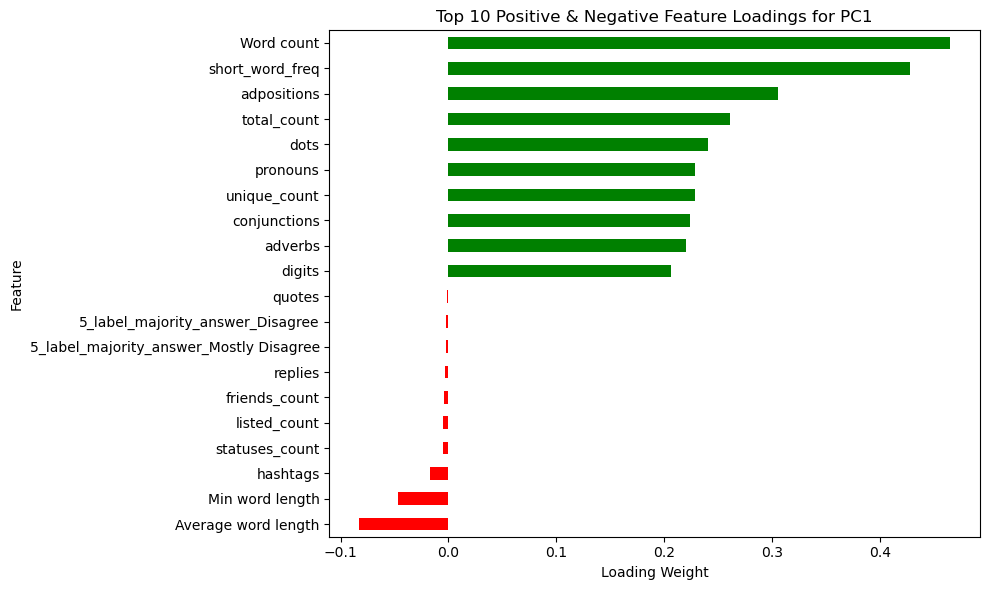

Top 10 positive loadings:
Word count         0.464959
short_word_freq    0.427056
adpositions        0.305351
total_count        0.260699
dots               0.240633
pronouns           0.228442
unique_count       0.228106
conjunctions       0.223818
adverbs            0.220213
digits             0.205852
dtype: float64

Top 10 negative loadings:
Average word length                       -0.082889
Min word length                           -0.047185
hashtags                                  -0.017529
statuses_count                            -0.005389
listed_count                              -0.005169
friends_count                             -0.004112
replies                                   -0.002835
5_label_majority_answer_Mostly Disagree   -0.002609
5_label_majority_answer_Disagree          -0.002140
quotes                                    -0.001381
dtype: float64


In [61]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt

# Drop Y columns
X = df_encoded.drop(columns=['BinaryNumTarget_x', 'BinaryNumTarget_y'])

# Scale 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA 
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

# Map PC1 to feature names
pc1_loadings = pd.Series(pca.components_[0], index=X.columns)

# Top 10 + & - loadings
top10_positive = pc1_loadings.sort_values(ascending=False).head(10)
top10_negative = pc1_loadings.sort_values().head(10)
top_features = pd.concat([top10_negative, top10_positive])

# horizontal bar chart 
colors = ['red' if val < 0 else 'green' for val in top_features]

plt.figure(figsize=(10,6))
top_features.sort_values().plot(kind='barh', color=colors)
plt.xlabel('Loading Weight')
plt.ylabel('Feature')
plt.title('Top 10 Positive & Negative Feature Loadings for PC1')
plt.tight_layout()
plt.show()

print("Top 10 positive loadings:")
print(top10_positive)
print("\nTop 10 negative loadings:")
print(top10_negative)


In [62]:
print("Columns used for PCA:")
print(list(X.columns))

Columns used for PCA:
['Unnamed: 0', 'followers_count', 'friends_count', 'statuses_count', 'listed_count', 'mentions', 'quotes', 'replies', 'retweets', 'favourites', 'hashtags', 'URLs', 'unique_count', 'total_count', 'Word count', 'Max word length', 'Min word length', 'Average word length', 'adverbs', 'adpositions', 'pronouns', 'TOs', 'determiners', 'conjunctions', 'dots', 'exclamation', 'questions', 'ampersand', 'capitals', 'digits', 'long_word_freq', 'short_word_freq', '5_label_majority_answer_Disagree', '5_label_majority_answer_Mostly Agree', '5_label_majority_answer_Mostly Disagree', '5_label_majority_answer_NO MAJORITY', '3_label_majority_answer_Disagree']


In [63]:
pc1_loadings = pd.Series(pca.components_[0], index=X.columns)

# Top 10 by absolute value
top10 = pc1_loadings.abs().sort_values(ascending=False).head(10)
print("Top contributors (with sign):")
print(pc1_loadings[top10.index])


Top contributors (with sign):
Word count         0.464959
short_word_freq    0.427056
adpositions        0.305351
total_count        0.260699
dots               0.240633
pronouns           0.228442
unique_count       0.228106
conjunctions       0.223818
adverbs            0.220213
digits             0.205852
dtype: float64


Sign of loadings don't really matter. It is the overall weight of it (bigger the number the more important it is). To find most relevant features, find the top absolute value feature loadindgs.